# Diamond Rain in Space — Cinematic Educational Video Notebook

This upgraded notebook keeps the **vertical cinematic explainer** style of the black-hole notebook, but rebuilds the story around a more space-grounded question:

> **Could diamond rain happen inside Uranus, Neptune, or similar exoplanets?**

What is improved in this version:

- **Stronger space framing** focused on the ice giants **Uranus and Neptune**.
- **Shorter and better-aligned on-screen text** for a cleaner cinematic look.
- **Back-of-the-envelope calculations** (pressure, depth, density contrast) so the story is better grounded.
- **Clearer scientific wording** that separates **hypothesis**, **laboratory evidence**, and **uncertainty**.
- **More cinematic titles and captions** that read better in a vertical video.

The result is still a self-contained notebook that can render:

1. a **storyboard preview** image, and
2. a **vertical MP4 explainer** video.


In [ ]:
# In a fresh Colab/Jupyter environment, uncomment this line:
# %pip install -U numpy pillow imageio imageio-ffmpeg tqdm


In [1]:
from __future__ import annotations

from pathlib import Path
import math
import random
import textwrap
import numpy as np
from PIL import Image, ImageDraw, ImageFont, ImageFilter
import imageio.v2 as imageio

try:
    from tqdm.auto import tqdm
except Exception:
    tqdm = lambda x, **kwargs: x

# ==========================
# Render settings
# ==========================
OUT_DIR = Path("diamond_rain_output")
OUT_DIR.mkdir(exist_ok=True)

DRAFT_MODE = True  # True = faster preview. False = sharper final render.

if DRAFT_MODE:
    W, H = 540, 960
    FPS = 18
else:
    W, H = 720, 1280
    FPS = 24

VIDEO_SECONDS = 88.0
NFRAMES = int(VIDEO_SECONDS * FPS)

VIDEO_NAME = OUT_DIR / "Diamond_Rain_Cinematic_Explainer.mp4"
STORYBOARD_NAME = OUT_DIR / "Diamond_Rain_Storyboard.png"

SEED = 314
random.seed(SEED)
np.random.seed(SEED)

# ==========================
# Planet facts + simple calculations
# ==========================
URANUS_RADIUS_KM = 25_362
NEPTUNE_RADIUS_KM = 24_622
URANUS_G = 8.69
NEPTUNE_G = 11.15
DIAMOND_DENSITY_G_CM3 = 3.51
INTERIOR_DENSITY_RANGE_KG_M3 = (700.0, 1500.0)  # simple order-of-magnitude range
PRESSURE_EXAMPLE_GPA = 100.0


def gpa_to_atm(gpa: float) -> float:
    return gpa * 1e9 / 101325.0


def depth_for_pressure_km(gpa: float, rho_kg_m3: float, g_m_s2: float) -> float:
    # Very simple hydrostatic estimate: P ~ rho * g * h
    return (gpa * 1e9) / (rho_kg_m3 * g_m_s2) / 1000.0


PRESSURE_EXAMPLE_ATM = gpa_to_atm(PRESSURE_EXAMPLE_GPA)
DEPTH_EXAMPLE_RANGE_KM = (
    min(
        depth_for_pressure_km(PRESSURE_EXAMPLE_GPA, rho, g)
        for rho in INTERIOR_DENSITY_RANGE_KG_M3
        for g in (URANUS_G, NEPTUNE_G)
    ),
    max(
        depth_for_pressure_km(PRESSURE_EXAMPLE_GPA, rho, g)
        for rho in INTERIOR_DENSITY_RANGE_KG_M3
        for g in (URANUS_G, NEPTUNE_G)
    ),
)

PRESSURE_CHIP = f"100 GPa ≈ {PRESSURE_EXAMPLE_ATM/1e6:.1f}M atm"
DEPTH_CHIP = f"several thousand km deep"
DENSITY_CHIP = f"ρdiamond ≈ {DIAMOND_DENSITY_G_CM3:.1f} g/cm³"
DENSITY_CHIP_2 = "denser than surrounding fluid"
URANUS_RADIUS_CHIP = f"R = {URANUS_RADIUS_KM:,} km"
NEPTUNE_RADIUS_CHIP = f"R = {NEPTUNE_RADIUS_KM:,} km"

# ==========================
# Fact notes used in the narration
# ==========================
FACT_NOTES = [
    "Diamond rain has not been directly observed inside Uranus or Neptune; it is a physically motivated hypothesis supported by laboratory experiments.",
    "The strongest space setting for the idea is the deep interior of the ice giants Uranus and Neptune, whose chemistry includes water, ammonia, methane, and hydrocarbons under high pressure.",
    "Methane and hydrocarbons provide carbon. Under extreme pressure and temperature, carbon-hydrogen bonds can break and carbon can rearrange into diamond structures.",
    "Laser-driven and X-ray experiments at facilities such as SLAC/LCLS and European XFEL have observed nanodiamond formation under conditions relevant to icy giant planets.",
    "Diamond is much denser than surrounding planetary fluid, so once crystals form they are expected to sink inward like a kind of deep precipitation.",
    "A simple hydrostatic estimate shows that pressures around 100 GPa correspond to almost one million Earth atmospheres and require several thousand kilometers of overlying material.",
    "Falling diamonds may redistribute carbon and heat, and may also influence conductive layers that help shape the unusual magnetic fields of Uranus and Neptune.",
    "Related chemistry may also occur inside mini-Neptune exoplanets. Older theoretical work has also discussed possible diamond formation in Jupiter and Saturn.",
]

SOURCES = {
    "NASA — Uranus Facts": "https://science.nasa.gov/uranus/facts/",
    "NASA — Neptune Facts": "https://science.nasa.gov/neptune/neptune-facts/",
    "NASA Gravity Assist — It’s Raining Diamonds on These Planets": "https://www.nasa.gov/podcasts/gravity-assist/gravity-assist-its-raining-diamonds-on-these-planets/",
    "SLAC 2017 — Scientists Create Diamond Rain": "https://www6.slac.stanford.edu/news/2017-08-21-scientists-create-diamond-rain-forms-interior-icy-giant-planets",
    "SLAC 2022 — Diamond Rain Could Be More Common": "https://www6.slac.stanford.edu/news/2022-09-02-diamond-rain-giant-icy-planets-could-be-more-common",
    "SLAC 2024 — Diamond Rain and Magnetic Fields": "https://www6.slac.stanford.edu/news/2024-01-08-diamond-rain-icy-planets-offers-clues-magnetic-field-mysteries",
    "European XFEL 2024 — New Findings on Diamond Rain": "https://www.xfel.eu/news_and_events/news/index_eng.html?openDirectAnchor=2269&two_columns=0",
    "Nature Astronomy 2024 — Diamond Precipitation Dynamics": "https://www.nature.com/articles/s41550-023-02147-x",
    "Science Advances 2022 — Oxygen-Assisted Diamond Formation": "https://www.science.org/doi/10.1126/sciadv.abo0617",
}

# ==========================
# Scene plan: space-grounded vertical explainer
# ==========================
SCENES = [
    {
        "start": 0.0, "end": 6.5, "kind": "hook",
        "eyebrow": "ALIEN WEATHER",
        "title": "It may rain diamonds",
        "caption": "Not at the cloud tops. Deep inside some giant planets, carbon may crystallize and fall inward."
    },
    {
        "start": 6.5, "end": 14.5, "kind": "worlds",
        "eyebrow": "BEST PLACES",
        "title": "Uranus and Neptune",
        "caption": "The best-supported space setting is the deep interior of the ice giants Uranus and Neptune."
    },
    {
        "start": 14.5, "end": 22.5, "kind": "ingredients",
        "eyebrow": "CARBON SOURCE",
        "title": "Methane feeds the process",
        "caption": "Methane and other hydrocarbons carry carbon — the ingredient needed to make diamond."
    },
    {
        "start": 22.5, "end": 31.5, "kind": "pressure",
        "eyebrow": "CRUSHING DEPTHS",
        "title": "Up to a million atmospheres",
        "caption": "Diamond-forming conditions may require tens to hundreds of gigapascals: immense pressure, immense depth."
    },
    {
        "start": 31.5, "end": 40.0, "kind": "chemistry",
        "eyebrow": "EXTREME CHEMISTRY",
        "title": "Carbon breaks and rearranges",
        "caption": "As pressure and temperature rise, carbon-hydrogen bonds can fail and carbon can form denser structures."
    },
    {
        "start": 40.0, "end": 48.5, "kind": "nucleation",
        "eyebrow": "CRYSTAL BIRTH",
        "title": "Nanodiamonds can form",
        "caption": "Laboratory experiments have observed tiny diamond crystals forming under relevant conditions."
    },
    {
        "start": 48.5, "end": 57.5, "kind": "rain",
        "eyebrow": "WHY IT FALLS",
        "title": "Diamonds are denser",
        "caption": "Once they form, diamond crystals should sink through surrounding fluid like deep planetary precipitation."
    },
    {
        "start": 57.5, "end": 67.5, "kind": "lab",
        "eyebrow": "THE EVIDENCE",
        "title": "Labs recreate planet interiors",
        "caption": "Powerful lasers compress hydrocarbon samples, and X-rays then reveal nanodiamonds forming."
    },
    {
        "start": 67.5, "end": 76.0, "kind": "magnetism",
        "eyebrow": "WHY IT MATTERS",
        "title": "It may affect giant planets",
        "caption": "Sinking diamonds could move heat and carbon, and may help explain unusual magnetic fields."
    },
    {
        "start": 76.0, "end": 83.0, "kind": "exoplanets",
        "eyebrow": "BEYOND OUR SOLAR SYSTEM",
        "title": "Mini-Neptunes may do it too",
        "caption": "Similar chemistry may happen inside many ice-rich exoplanets, one of the most common planet classes."
    },
    {
        "start": 83.0, "end": 88.0, "kind": "takeaway",
        "eyebrow": "THE TAKEAWAY",
        "title": "Diamond rain is plausible",
        "caption": "We have not seen it directly, but space physics and lab experiments make it a serious planetary idea."
    },
]


In [2]:
# ==========================
# Fonts, easing, layout helpers
# ==========================
def font_path(bold: bool = False) -> str | None:
    candidates = [
        "/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf" if bold else "/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf",
        "/usr/share/fonts/truetype/liberation2/LiberationSans-Bold.ttf" if bold else "/usr/share/fonts/truetype/liberation2/LiberationSans-Regular.ttf",
        "/System/Library/Fonts/Supplemental/Arial Bold.ttf" if bold else "/System/Library/Fonts/Supplemental/Arial.ttf",
        "/Library/Fonts/Arial Bold.ttf" if bold else "/Library/Fonts/Arial.ttf",
    ]
    for p in candidates:
        if p and Path(p).exists():
            return p
    return None


def load_font(size: int, bold: bool = False):
    p = font_path(bold)
    if p:
        return ImageFont.truetype(p, size)
    return ImageFont.load_default()


FONT_EYEBROW = load_font(max(16, W // 31), True)
FONT_CAPTION = load_font(max(22, W // 24), False)
FONT_LABEL = load_font(max(15, W // 37), True)
FONT_TINY = load_font(max(12, W // 46), False)

TITLE_SIZE_CANDIDATES = [max(38, W // 9), max(34, W // 10), max(30, W // 11), max(27, W // 12), max(24, W // 13)]
CAPTION_SIZE_CANDIDATES = [max(24, W // 23), max(22, W // 24), max(20, W // 26), max(18, W // 28)]

COLORS = {
    "bg0": (2, 5, 13),
    "bg1": (7, 18, 38),
    "ice": (112, 225, 255),
    "cyan": (105, 214, 255),
    "blue": (70, 130, 255),
    "deep": (22, 44, 92),
    "violet": (166, 116, 255),
    "gold": (255, 216, 120),
    "diamond": (228, 250, 255),
    "white": (245, 248, 255),
    "muted": (172, 190, 218),
}


def clamp(x: float, lo: float = 0.0, hi: float = 1.0) -> float:
    return max(lo, min(hi, x))


def lerp(a: float, b: float, u: float) -> float:
    return a + (b - a) * u


def smoothstep(edge0: float, edge1: float, x: float) -> float:
    x = clamp((x - edge0) / max(1e-9, edge1 - edge0))
    return x * x * (3 - 2 * x)


def ease_in_out(u: float) -> float:
    u = clamp(u)
    return 0.5 - 0.5 * math.cos(math.pi * u)


def ease_out(u: float) -> float:
    u = clamp(u)
    return 1 - (1 - u) ** 3


def text_size(draw: ImageDraw.ImageDraw, text: str, font) -> tuple[int, int]:
    box = draw.textbbox((0, 0), text, font=font)
    return box[2] - box[0], box[3] - box[1]


def wrap_lines(draw: ImageDraw.ImageDraw, text: str, font, max_width: int) -> list[str]:
    words = text.split()
    lines, line = [], ""
    for word in words:
        test = (line + " " + word).strip()
        if text_size(draw, test, font)[0] <= max_width:
            line = test
        else:
            if line:
                lines.append(line)
            line = word
    if line:
        lines.append(line)
    return lines


def fit_wrapped_text(text: str, size_candidates: list[int], max_width: int, max_lines: int, bold: bool = False):
    d = ImageDraw.Draw(Image.new("RGBA", (W, H), (0, 0, 0, 0)))
    fallback = None
    for size in size_candidates:
        font = load_font(size, bold=bold)
        lines = wrap_lines(d, text, font, max_width)
        fallback = (font, lines)
        if len(lines) <= max_lines:
            return font, lines
    font, lines = fallback
    return font, lines[:max_lines]


def draw_glow_text(
    img: Image.Image,
    xy: tuple[int, int],
    text: str,
    font,
    fill=(255, 255, 255, 255),
    anchor: str = "mm",
    glow=(105, 214, 255, 120),
    blur: int = 10,
    stroke: int = 0,
):
    layer = Image.new("RGBA", img.size, (0, 0, 0, 0))
    d = ImageDraw.Draw(layer)
    d.text(xy, text, font=font, fill=glow, anchor=anchor, stroke_width=stroke, stroke_fill=(0, 0, 0, 160))
    img.alpha_composite(layer.filter(ImageFilter.GaussianBlur(blur)))
    d = ImageDraw.Draw(img)
    d.text(xy, text, font=font, fill=fill, anchor=anchor, stroke_width=stroke, stroke_fill=(0, 0, 0, 200))


def draw_multiline_centered(img: Image.Image, lines: list[str], y_center: int, font, fill=(235, 242, 255, 235), line_gap: int = 8, glow=None, blur: int = 0, stroke: int = 0):
    d = ImageDraw.Draw(img)
    heights = [text_size(d, line, font)[1] for line in lines]
    total_h = sum(heights) + line_gap * (len(lines) - 1)
    yy = y_center - total_h // 2
    for line, lh in zip(lines, heights):
        if glow is not None:
            draw_glow_text(img, (W // 2, yy + lh // 2), line, font, fill=fill, glow=glow, blur=blur, stroke=stroke)
        else:
            tw, _ = text_size(d, line, font)
            d.text(((W - tw) // 2, yy), line, font=font, fill=fill)
        yy += lh + line_gap


def add_vignette(img: Image.Image, strength: float = 0.55):
    yy, xx = np.mgrid[0:H, 0:W]
    cx, cy = W / 2, H / 2
    r = np.sqrt(((xx - cx) / W) ** 2 + ((yy - cy) / H) ** 2)
    u = np.clip((r - 0.20) / max(1e-9, 0.72 - 0.20), 0, 1)
    vignette = u * u * (3 - 2 * u)
    mask = np.uint8(255 * clamp(strength) * vignette)
    mask_img = Image.fromarray(mask, "L")
    dark = Image.new("RGBA", img.size, (0, 0, 0, 255))
    img.alpha_composite(Image.composite(dark, Image.new("RGBA", img.size, (0, 0, 0, 0)), mask_img))


def draw_scene_text(img: Image.Image, scene: dict, local: float):
    d = ImageDraw.Draw(img, "RGBA")
    a = int(255 * smoothstep(0.06, 0.18, local) * (1 - smoothstep(0.90, 1.0, local)))

    panel = Image.new("RGBA", img.size, (0, 0, 0, 0))
    pd = ImageDraw.Draw(panel, "RGBA")
    top_box = [int(W * 0.05), int(H * 0.045), int(W * 0.95), int(H * 0.33)]
    bottom_box = [int(W * 0.05), int(H * 0.73), int(W * 0.95), int(H * 0.91)]
    pd.rounded_rectangle(top_box, radius=30, fill=(4, 10, 26, int(112 * a / 255)), outline=(105, 214, 255, int(50 * a / 255)))
    pd.rounded_rectangle(bottom_box, radius=30, fill=(4, 10, 26, int(135 * a / 255)), outline=(255, 255, 255, int(40 * a / 255)))
    img.alpha_composite(panel)

    d.text((int(W * 0.085), int(H * 0.078)), scene["eyebrow"], font=FONT_EYEBROW, fill=(130, 230, 255, a))

    title_font, title_lines = fit_wrapped_text(scene["title"], TITLE_SIZE_CANDIDATES, int(W * 0.76), 3, bold=True)
    draw_multiline_centered(
        img,
        title_lines,
        int(H * 0.18),
        title_font,
        fill=(245, 248, 255, a),
        line_gap=max(6, H // 120),
        glow=(80, 190, 255, int(95 * a / 255)),
        blur=9,
        stroke=1,
    )

    caption_font, caption_lines = fit_wrapped_text(scene["caption"], CAPTION_SIZE_CANDIDATES, int(W * 0.80), 4, bold=False)
    draw_multiline_centered(
        img,
        caption_lines,
        int(H * 0.82),
        caption_font,
        fill=(235, 245, 255, a),
        line_gap=max(7, H // 120),
    )


def draw_progress(img: Image.Image, t: float):
    d = ImageDraw.Draw(img, "RGBA")
    pad = int(W * 0.06)
    y = int(H * 0.94)
    d.rounded_rectangle([pad, y, W - pad, y + 5], radius=3, fill=(255, 255, 255, 36))
    x = pad + int((W - 2 * pad) * clamp(t / VIDEO_SECONDS))
    d.rounded_rectangle([pad, y, x, y + 5], radius=3, fill=(105, 214, 255, 210))


def draw_chip(img: Image.Image, text: str, xy: tuple[int, int], color=(105, 214, 255), alpha: int = 210):
    d = ImageDraw.Draw(img, "RGBA")
    tw, th = text_size(d, text, FONT_LABEL)
    x, y = xy
    d.rounded_rectangle(
        [x - tw // 2 - 12, y - th // 2 - 8, x + tw // 2 + 12, y + th // 2 + 8],
        radius=14,
        fill=(4, 12, 30, int(alpha * 0.62)),
        outline=(*color, int(alpha * 0.55)),
    )
    d.text((x - tw // 2, y - th // 2), text, font=FONT_LABEL, fill=(245, 250, 255, alpha))


In [3]:
# ==========================
# Deterministic procedural assets
# ==========================
rng = np.random.default_rng(SEED)

STAR_COUNT = 620 if DRAFT_MODE else 1050
STAR_X = rng.random(STAR_COUNT) * W
STAR_Y = rng.random(STAR_COUNT) * H
STAR_Z = rng.random(STAR_COUNT) * 1.0 + 0.25
STAR_SIZE = rng.random(STAR_COUNT) * 1.55 + 0.25
STAR_TWINKLE = rng.random(STAR_COUNT) * math.tau

DIAMOND_TRAILS = []
for i in range(70 if DRAFT_MODE else 115):
    DIAMOND_TRAILS.append({
        "x": float(rng.uniform(W*0.12, W*0.88)),
        "y": float(rng.uniform(-H*0.1, H*1.05)),
        "speed": float(rng.uniform(22, 82)),
        "size": float(rng.uniform(4, 15)),
        "phase": float(rng.random() * math.tau),
        "depth": float(rng.uniform(0.35, 1.0)),
    })

MOLECULES = []
for i in range(34 if DRAFT_MODE else 56):
    MOLECULES.append({
        "x": float(rng.uniform(W*0.12, W*0.88)),
        "y": float(rng.uniform(H*0.30, H*0.68)),
        "r": float(rng.uniform(18, 34)),
        "phase": float(rng.random() * math.tau),
    })

# Precomputed coordinate maps for fast backgrounds/vignettes.
YY, XX = np.mgrid[0:H, 0:W]
XN = XX / W
YN = YY / H


def nebula_background(t: float, hue_shift: float = 0.0) -> Image.Image:
    # Deep blue procedural gradient with gentle moving bands.
    band = 0.5 + 0.5 * np.sin(10 * XN + 6 * YN + t * 0.30 + hue_shift)
    sweep = 0.5 + 0.5 * np.sin(4 * XN - 7 * YN + t * 0.18)
    vertical = YN
    arr = np.zeros((H, W, 3), dtype=np.uint8)
    arr[..., 0] = np.uint8(2 + 14 * vertical + 12 * sweep)
    arr[..., 1] = np.uint8(7 + 34 * vertical + 28 * band)
    arr[..., 2] = np.uint8(24 + 82 * vertical + 68 * sweep)
    img = Image.fromarray(arr, "RGB").convert("RGBA")

    d = ImageDraw.Draw(img, "RGBA")
    # soft aurora bands
    for k in range(4):
        y = int(H * (0.18 + 0.17*k + 0.025*math.sin(t*0.25 + k)))
        d.ellipse([int(-W*0.2), y-int(H*0.11), int(W*1.2), y+int(H*0.10)], fill=(40, 160, 220, 12), outline=None)
    # stars
    for x, y, z, s, ph in zip(STAR_X, STAR_Y, STAR_Z, STAR_SIZE, STAR_TWINKLE):
        tw = 0.55 + 0.45 * math.sin(t * (0.6 + z) + ph)
        a = int(65 + 155 * tw * min(1, z))
        rr = max(1, int(s * (0.65 + z*0.45)))
        sx = int((x + t * 2.2 / z) % W)
        sy = int(y)
        d.ellipse([sx-rr, sy-rr, sx+rr, sy+rr], fill=(210, 242, 255, a))
    return img


def draw_planet(img: Image.Image, cx: int, cy: int, r: int, t: float, color_shift: float = 0.0, cutaway: bool = False):
    layer = Image.new("RGBA", img.size, (0,0,0,0))
    d = ImageDraw.Draw(layer, "RGBA")
    # glow
    for k in range(12, 0, -1):
        rr = r + k * int(W*0.012)
        d.ellipse([cx-rr, cy-rr, cx+rr, cy+rr], fill=(55, 180, 255, int(5*k)))
    # body with rings/bands
    d.ellipse([cx-r, cy-r, cx+r, cy+r], fill=(55, 150, 210, 245), outline=(175, 240, 255, 170), width=max(2, W//140))
    for k in range(-5, 6):
        yy = cy + int(k * r * 0.16 + 8*math.sin(t*0.25 + k))
        h = int(r * (0.10 + 0.02*math.cos(k)))
        a = int(26 + 20 * (1 - abs(k)/7))
        col = (125, 230, 255, a) if k % 2 == 0 else (40, 90, 200, a)
        d.ellipse([cx-r, yy-h, cx+r, yy+h], fill=col)
    # limb shadow
    shade = Image.new("RGBA", img.size, (0,0,0,0))
    sd = ImageDraw.Draw(shade, "RGBA")
    sd.ellipse([cx-r, cy-r, cx+r, cy+r], fill=(0,0,0,0))
    for k in range(8):
        rr = r - k*int(r*0.05)
        sd.pieslice([cx-rr, cy-rr, cx+rr, cy+rr], start=260, end=90, fill=(0,0,20, int(18+6*k)))
    layer.alpha_composite(shade)

    if cutaway:
        # Remove a wedge and show deep interior layers.
        wedge = [(cx, cy), (cx+r, cy-int(r*0.62)), (cx+r, cy+int(r*0.62))]
        d.polygon(wedge, fill=(8, 18, 42, 245))
        for frac, col in [(0.78,(22,60,135,230)), (0.58,(35,115,165,220)), (0.38,(50,155,190,210)), (0.20,(235,245,255,180))]:
            rr = int(r*frac)
            d.pieslice([cx-rr, cy-rr, cx+rr, cy+rr], start=-42, end=42, fill=col)
        d.line([cx, cy, cx+r, cy-int(r*0.62)], fill=(210,250,255,160), width=2)
        d.line([cx, cy, cx+r, cy+int(r*0.62)], fill=(210,250,255,160), width=2)
    img.alpha_composite(layer.filter(ImageFilter.GaussianBlur(0.25)))


def draw_diamond(img: Image.Image, cx: int, cy: int, size: int, angle: float = 0.0, alpha: int = 230, label: bool = False):
    # Faceted stylized diamond/crystal.
    pts = np.array([
        [0, -1.00], [0.68, -0.25], [0.42, 0.72], [0, 1.05], [-0.42, 0.72], [-0.68, -0.25]
    ], dtype=float)
    ca, sa = math.cos(angle), math.sin(angle)
    rot = np.array([[ca, -sa], [sa, ca]])
    pts = pts @ rot.T
    poly = [(int(cx + x*size), int(cy + y*size)) for x, y in pts]
    d = ImageDraw.Draw(img, "RGBA")
    d.polygon(poly, fill=(205, 246, 255, int(alpha*0.70)), outline=(255,255,255,alpha))
    top = (cx, cy - int(size*0.95))
    left = (cx - int(size*0.68), cy - int(size*0.25))
    right = (cx + int(size*0.68), cy - int(size*0.25))
    bottom = (cx, cy + int(size*1.05))
    d.line([left, bottom, right, top, left], fill=(255,255,255,int(alpha*0.72)), width=max(1,size//7))
    d.line([top, bottom], fill=(150,230,255,int(alpha*0.55)), width=max(1,size//8))
    d.line([left, right], fill=(255,255,255,int(alpha*0.45)), width=max(1,size//10))
    # sparkle
    d.line([cx-size//2, cy-size//2, cx+size//2, cy+size//2], fill=(255,255,255,int(alpha*0.35)), width=1)
    if label:
        draw_chip(img, "carbon crystal", (cx, cy + int(size*1.75)), color=(210,245,255), alpha=min(alpha, 220))


def draw_falling_diamonds(img: Image.Image, t: float, local: float, density: float = 1.0, deep: bool = False):
    d = ImageDraw.Draw(img, "RGBA")
    for i, p in enumerate(DIAMOND_TRAILS):
        if i / len(DIAMOND_TRAILS) > density:
            continue
        y = (p["y"] + t * p["speed"] * (0.6 + p["depth"])) % (H + 90) - 45
        x = p["x"] + 13 * math.sin(t*0.75 + p["phase"])
        size = int(p["size"] * (0.7 + 0.45*p["depth"]))
        alpha = int((80 + 150*p["depth"]) * smoothstep(0.05, 0.35, local))
        if deep:
            d.line([int(x), int(y-size*4), int(x), int(y-size)], fill=(115,220,255,int(alpha*0.25)), width=1)
        draw_diamond(img, int(x), int(y), max(3,size), angle=t*0.35+p["phase"], alpha=alpha)


def draw_methane_molecule(img: Image.Image, x: int, y: int, r: int, t: float, alpha: int = 220, broken: float = 0.0):
    d = ImageDraw.Draw(img, "RGBA")
    # Carbon center and four hydrogen nodes. broken moves H away from center.
    d.ellipse([x-r//3, y-r//3, x+r//3, y+r//3], fill=(40, 50, 65, alpha), outline=(255,255,255,int(alpha*0.70)), width=2)
    d.text((x-5, y-8), "C", font=FONT_TINY, fill=(245,250,255,alpha))
    angles = [math.radians(a + 12*math.sin(t*0.6)) for a in (30, 150, 250, 315)]
    for j, ang in enumerate(angles):
        dist = r * (0.82 + 0.75*broken + 0.08*math.sin(t+j))
        hx = int(x + math.cos(ang)*dist)
        hy = int(y + math.sin(ang)*dist)
        bond_a = int(alpha * (1 - 0.75*broken))
        d.line([x, y, hx, hy], fill=(150,230,255,bond_a), width=max(1, r//13))
        rr = max(4, r//5)
        d.ellipse([hx-rr, hy-rr, hx+rr, hy+rr], fill=(205,240,255,int(alpha*0.85)), outline=(255,255,255,int(alpha*0.6)))
        d.text((hx-4, hy-7), "H", font=FONT_TINY, fill=(10,30,55,int(alpha*0.9)))


def draw_depth_column(img: Image.Image, x0: int, y0: int, x1: int, y1: int, progress: float, labels: bool = True):
    d = ImageDraw.Draw(img, "RGBA")
    for i in range(y0, y1):
        u = (i - y0) / max(1, y1-y0)
        col = (
            int(20 + 55*u),
            int(70 + 90*u),
            int(150 + 55*(1-u)),
            190,
        )
        d.line([x0, i, x1, i], fill=col)
    d.rounded_rectangle([x0, y0, x1, y1], radius=22, outline=(190,240,255,160), width=2)
    y = int(y0 + (y1-y0) * progress)
    d.line([x0-8, y, x1+8, y], fill=(255,225,130,220), width=4)
    d.polygon([(x1+10,y), (x1+28,y-9), (x1+28,y+9)], fill=(255,225,130,220))
    if labels:
        d.text((x0, y0-28), "clouds", font=FONT_TINY, fill=(220,240,255,210))
        d.text((x0, y1+10), "deeper interior", font=FONT_TINY, fill=(220,240,255,210))
        d.text((x1+34, y-12), "P ↑  T ↑", font=FONT_LABEL, fill=(255,225,130,230))


In [4]:
# ==========================
# Scene visual functions
# ==========================
def scene_hook(img: Image.Image, t: float, local: float):
    cx, cy = W//2, int(H*0.50)
    draw_planet(img, cx, cy, int(W*0.34), t, cutaway=True)
    # Deep cutaway diamond rain
    mask_layer = Image.new("RGBA", img.size, (0,0,0,0))
    draw_falling_diamonds(mask_layer, t, local, density=0.75, deep=True)
    img.alpha_composite(mask_layer)
    d = ImageDraw.Draw(img, "RGBA")
    a = int(210 * smoothstep(0.25, 0.65, local))
    d.text((int(W*0.09), int(H*0.63)), "deep interior", font=FONT_LABEL, fill=(130,230,255,a))
    d.text((int(W*0.09), int(H*0.665)), "best-known case: ice giants", font=FONT_TINY, fill=(255,230,155,a))


def scene_worlds(img: Image.Image, t: float, local: float):
    draw_planet(img, int(W*0.30), int(H*0.47), int(W*0.19), t, color_shift=0.1)
    draw_planet(img, int(W*0.70), int(H*0.49), int(W*0.22), t+3, color_shift=0.4)
    d = ImageDraw.Draw(img, "RGBA")
    a = int(230 * smoothstep(0.15, 0.55, local))
    draw_chip(img, "URANUS", (int(W*0.30), int(H*0.66)), color=(170,250,255), alpha=a)
    d.text((int(W*0.22), int(H*0.695)), URANUS_RADIUS_CHIP, font=FONT_TINY, fill=(225,240,255,a))
    draw_chip(img, "NEPTUNE", (int(W*0.70), int(H*0.69)), color=(115,175,255), alpha=a)
    d.text((int(W*0.61), int(H*0.725)), NEPTUNE_RADIUS_CHIP, font=FONT_TINY, fill=(225,240,255,a))
    # Methane absorption visual: red-light filter
    d.line([int(W*0.08), int(H*0.28), int(W*0.48), int(H*0.40)], fill=(255,80,80,int(120*a/255)), width=2)
    d.text((int(W*0.10), int(H*0.245)), "methane affects color", font=FONT_TINY, fill=(225,240,255,a))
    d.line([int(W*0.92), int(H*0.30), int(W*0.52), int(H*0.42)], fill=(105,214,255,int(150*a/255)), width=2)


def scene_ingredients(img: Image.Image, t: float, local: float):
    d = ImageDraw.Draw(img, "RGBA")
    # molecules drifting around a central ingredient label
    for i, p in enumerate(MOLECULES[:18]):
        x = int(p["x"] + 15*math.sin(t*0.7 + p["phase"]))
        y = int(p["y"] + 10*math.cos(t*0.8 + p["phase"]))
        alpha = int(85 + 120*smoothstep(0.08, 0.45, local))
        draw_methane_molecule(img, x, y, int(p["r"]), t+p["phase"], alpha=alpha, broken=0)
    # equation card
    a = int(240 * smoothstep(0.20, 0.60, local))
    d.rounded_rectangle([int(W*0.11), int(H*0.64), int(W*0.89), int(H*0.72)], radius=20, fill=(5,15,35,int(135*a/255)), outline=(105,214,255,int(80*a/255)))
    formula = "CH₄ + hydrocarbons  →  carbon source"
    tw, th = text_size(d, formula, FONT_LABEL)
    d.text((W//2-tw//2, int(H*0.672)), formula, font=FONT_LABEL, fill=(245,250,255,a))
    draw_chip(img, "methane", (int(W*0.24), int(H*0.29)), color=(105,214,255), alpha=a)
    draw_chip(img, "hydrocarbons", (int(W*0.72), int(H*0.34)), color=(166,116,255), alpha=a)


def scene_pressure(img: Image.Image, t: float, local: float):
    d = ImageDraw.Draw(img, "RGBA")
    draw_planet(img, int(W*0.38), int(H*0.50), int(W*0.26), t, cutaway=True)
    p = ease_in_out(local)
    draw_depth_column(img, int(W*0.72), int(H*0.30), int(W*0.84), int(H*0.67), p)
    y = int(H*0.30 + (H*0.37)*p)
    # pressure rings around moving parcel
    for k in range(5):
        rr = int(W*(0.04 + 0.035*k + 0.03*math.sin(t+k)))
        a = int(90 * smoothstep(0.15,0.65,local) * (1-k/6))
        d.ellipse([int(W*0.38)-rr, y-rr, int(W*0.38)+rr, y+rr], outline=(255,225,130,a), width=2)
    draw_methane_molecule(img, int(W*0.38), y, int(W*0.07), t, alpha=220, broken=0.15*p)
    draw_chip(img, PRESSURE_CHIP, (int(W*0.33), int(H*0.71)), color=(255,225,130), alpha=int(220*smoothstep(0.25,0.8,local)))
    draw_chip(img, DEPTH_CHIP, (int(W*0.66), int(H*0.75)), color=(255,150,110), alpha=int(220*smoothstep(0.35,0.85,local)))


def scene_chemistry(img: Image.Image, t: float, local: float):
    d = ImageDraw.Draw(img, "RGBA")
    # left: intact molecules. right: carbon network.
    for i, p in enumerate(MOLECULES[:10]):
        x = int(W*0.22 + 65*math.cos(i*math.tau/10 + t*0.2))
        y = int(H*0.48 + 130*math.sin(i*math.tau/10 + t*0.2))
        broken = smoothstep(0.20, 0.75, local)
        draw_methane_molecule(img, x, y, int(W*0.045), t+i, alpha=180, broken=broken)
    # arrow
    a = int(220*smoothstep(0.25,0.65,local))
    d.line([int(W*0.38), int(H*0.49), int(W*0.61), int(H*0.49)], fill=(255,225,130,a), width=4)
    d.polygon([(int(W*0.61), int(H*0.49)), (int(W*0.58), int(H*0.47)), (int(W*0.58), int(H*0.51))], fill=(255,225,130,a))
    # carbon lattice grid
    nodes = []
    for row in range(4):
        for col in range(4):
            x = int(W*0.67 + (col-1.5)*W*0.06 + (row%2)*W*0.025)
            y = int(H*0.39 + row*H*0.055)
            nodes.append((x,y))
    for i, (x,y) in enumerate(nodes):
        for j, (x2,y2) in enumerate(nodes):
            if j > i and (abs(x-x2) < W*0.075 and abs(y-y2) < H*0.07):
                d.line([x,y,x2,y2], fill=(160,235,255,int(95*smoothstep(0.45,0.85,local))), width=2)
    for x,y in nodes:
        d.ellipse([x-6,y-6,x+6,y+6], fill=(240,250,255,int(215*smoothstep(0.38,0.78,local))))
    draw_chip(img, "C-H bonds break", (int(W*0.25), int(H*0.68)), color=(255,225,130), alpha=a)
    draw_chip(img, "carbon reorganizes", (int(W*0.70), int(H*0.68)), color=(105,214,255), alpha=a)


def scene_nucleation(img: Image.Image, t: float, local: float):
    d = ImageDraw.Draw(img, "RGBA")
    # A growing central diamond made of many facets.
    cx, cy = W//2, int(H*0.48)
    for i in range(28):
        angle = i * math.tau / 28 + t*0.08
        rad = int(W * (0.10 + 0.13*smoothstep(0.2,0.8,local)) * (0.65 + 0.25*math.sin(i)))
        x = cx + int(math.cos(angle)*rad)
        y = cy + int(math.sin(angle)*rad*0.72)
        aa = int(40 + 105*smoothstep(0.1,0.7,local))
        d.line([cx, cy, x, y], fill=(105,214,255,aa), width=1)
        d.ellipse([x-4,y-4,x+4,y+4], fill=(230,250,255,aa))
    size = int(W*(0.06 + 0.10*smoothstep(0.16,0.80,local)))
    draw_diamond(img, cx, cy, size, angle=0.1*math.sin(t), alpha=240, label=True)
    # small nanodiamonds
    for i in range(12):
        x = int(cx + math.cos(i*math.tau/12+t*0.35)*W*0.28)
        y = int(cy + math.sin(i*math.tau/12+t*0.35)*H*0.17)
        draw_diamond(img, x, y, int(W*0.018), angle=t+i, alpha=int(125*smoothstep(0.35,0.8,local)))
    draw_chip(img, "nanodiamonds", (W//2, int(H*0.69)), color=(225,250,255), alpha=int(225*smoothstep(0.35,0.75,local)))
    d.text((int(W*0.30), int(H*0.73)), "seen in lab experiments", font=FONT_TINY, fill=(225,240,255,int(210*smoothstep(0.45,0.85,local))))


def scene_rain(img: Image.Image, t: float, local: float):
    d = ImageDraw.Draw(img, "RGBA")
    # Layered interior column + rain.
    for k in range(8):
        y0 = int(H*(0.24 + k*0.065))
        col = (10+k*10, 45+k*18, 100+k*14, 54)
        d.rectangle([int(W*0.08), y0, int(W*0.92), y0+int(H*0.055)], fill=col)
    draw_falling_diamonds(img, t, local, density=1.0, deep=True)
    # big falling diamond with trail
    x = W//2
    y = int(H*(0.28 + 0.34*ease_in_out(local)))
    d.line([x, y-int(H*0.18), x, y-int(W*0.08)], fill=(145,230,255,105), width=4)
    draw_diamond(img, x, y, int(W*0.065), angle=t*0.25, alpha=245)
    draw_chip(img, DENSITY_CHIP, (int(W*0.50), int(H*0.68)), color=(255,225,130), alpha=int(225*smoothstep(0.25,0.75,local)))
    draw_chip(img, DENSITY_CHIP_2, (int(W*0.50), int(H*0.725)), color=(105,214,255), alpha=int(225*smoothstep(0.35,0.85,local)))


def scene_lab(img: Image.Image, t: float, local: float):
    d = ImageDraw.Draw(img, "RGBA")
    # Lab table / sample chamber
    chamber = [int(W*0.18), int(H*0.40), int(W*0.82), int(H*0.60)]
    d.rounded_rectangle(chamber, radius=24, fill=(5, 12, 32, 185), outline=(180,235,255,130), width=2)
    # plastic sample strip
    sx0, sy0, sx1, sy1 = int(W*0.43), int(H*0.47), int(W*0.57), int(H*0.53)
    d.rounded_rectangle([sx0, sy0, sx1, sy1], radius=10, fill=(160,180,230,145), outline=(245,250,255,180))
    d.text((sx0-8, sy1+12), "hydrocarbon plastic", font=FONT_TINY, fill=(220,235,255,210))
    # lasers left/right
    beam_a = int(220 * smoothstep(0.15,0.55,local))
    for side in [-1, 1]:
        xstart = int(W*(0.08 if side < 0 else 0.92))
        xend = int(W*(0.43 if side < 0 else 0.57))
        y = int(H*0.50)
        col = (105,214,255,beam_a) if side < 0 else (255,100,165,beam_a)
        d.line([xstart,y,xend,y], fill=col, width=max(3,W//90))
        d.polygon([(xend,y), (xend - side*18, y-10), (xend - side*18, y+10)], fill=col)
    # shock waves and x-ray detector
    for k in range(5):
        rr = int(W*(0.055 + 0.035*k + 0.02*math.sin(t*2+k)))
        d.ellipse([W//2-rr, int(H*0.50)-rr, W//2+rr, int(H*0.50)+rr], outline=(255,225,130,int(90*(1-k/6)*smoothstep(0.25,0.75,local))), width=2)
    # X-ray pulses upward
    for i in range(6):
        x = int(W*0.36 + i*W*0.055)
        d.line([x, int(H*0.34), x+int(W*0.16), int(H*0.67)], fill=(245,250,255,int(40+25*i)), width=1)
    # nanodiamond dots inside sample
    for i in range(20):
        x = int(rng.integers(sx0+5, sx1-5))
        y = int(rng.integers(sy0+5, sy1-5))
        d.ellipse([x-2,y-2,x+2,y+2], fill=(240,255,255,int(190*smoothstep(0.45,0.90,local))))
    draw_chip(img, "laser shock compression", (int(W*0.50), int(H*0.30)), color=(105,214,255), alpha=beam_a)
    draw_chip(img, "X-rays catch nanodiamonds", (int(W*0.50), int(H*0.70)), color=(255,225,130), alpha=int(220*smoothstep(0.40,0.85,local)))


def scene_magnetism(img: Image.Image, t: float, local: float):
    d = ImageDraw.Draw(img, "RGBA")
    cx, cy = W//2, int(H*0.49)
    draw_planet(img, cx, cy, int(W*0.25), t, cutaway=True)
    # tilted magnetic field lines
    theta = math.radians(-28)
    ca, sa = math.cos(theta), math.sin(theta)
    for k in range(7):
        rr_x = int(W*(0.24 + k*0.055))
        rr_y = int(H*(0.10 + k*0.035))
        pts = []
        for j in range(130):
            a = j * math.tau / 129
            x = rr_x * math.cos(a)
            y = rr_y * math.sin(a)
            xr = ca*x - sa*y + cx
            yr = sa*x + ca*y + cy
            pts.append((int(xr), int(yr)))
        d.line(pts, fill=(105,214,255,int((80-k*8)*smoothstep(0.15,0.65,local))), width=2)
    # diamond stirring layer
    for i in range(18):
        x = int(cx + math.cos(i*math.tau/18+t*0.5)*W*0.18)
        y = int(cy + math.sin(i*math.tau/18+t*0.5)*H*0.10)
        draw_diamond(img, x, y, int(W*0.016), angle=t+i, alpha=int(130*smoothstep(0.35,0.8,local)))
    draw_chip(img, "conductive ice currents", (W//2, int(H*0.70)), color=(105,214,255), alpha=int(220*smoothstep(0.35,0.75,local)))
    draw_chip(img, "possible magnetic clue", (W//2, int(H*0.745)), color=(255,225,130), alpha=int(220*smoothstep(0.45,0.85,local)))


def scene_exoplanets(img: Image.Image, t: float, local: float):
    d = ImageDraw.Draw(img, "RGBA")
    # solar system ice giants + many mini-Neptunes
    draw_planet(img, int(W*0.25), int(H*0.48), int(W*0.16), t)
    draw_planet(img, int(W*0.58), int(H*0.50), int(W*0.19), t+2)
    for i in range(7):
        angle = i * math.tau/7 + t*0.08
        x = int(W*0.74 + math.cos(angle)*W*0.13)
        y = int(H*0.44 + math.sin(angle)*H*0.15)
        r = int(W*(0.035 + 0.018*(i%3)))
        d.ellipse([x-r,y-r,x+r,y+r], fill=(40,130,220,180), outline=(160,240,255,150))
        if i % 2 == 0:
            draw_diamond(img, x, y+r+10, int(W*0.011), angle=t, alpha=int(160*smoothstep(0.35,0.8,local)))
    draw_chip(img, "mini-Neptunes", (int(W*0.75), int(H*0.67)), color=(166,116,255), alpha=int(225*smoothstep(0.25,0.7,local)))
    draw_chip(img, "common exoplanet type", (int(W*0.75), int(H*0.725)), color=(105,214,255), alpha=int(225*smoothstep(0.35,0.8,local)))


def scene_takeaway(img: Image.Image, t: float, local: float):
    cx, cy = W//2, int(H*0.48)
    draw_planet(img, cx, cy, int(W*0.30), t, cutaway=True)
    draw_falling_diamonds(img, t, local, density=0.80, deep=True)
    d = ImageDraw.Draw(img, "RGBA")
    bullets = [
        "best case: Uranus and Neptune",
        "100 GPa is about one million atmospheres",
        "lab experiments produce nanodiamonds",
        "direct observation inside planets: not yet",
    ]
    a = int(230 * smoothstep(0.20, 0.75, local))
    y0 = int(H*0.68)
    for i, b in enumerate(bullets):
        yy = y0 + i * int(H*0.035)
        d.ellipse([int(W*0.13)-4, yy+5, int(W*0.13)+4, yy+13], fill=(105,214,255,a))
        d.text((int(W*0.16), yy), b, font=FONT_TINY, fill=(230,245,255,a))


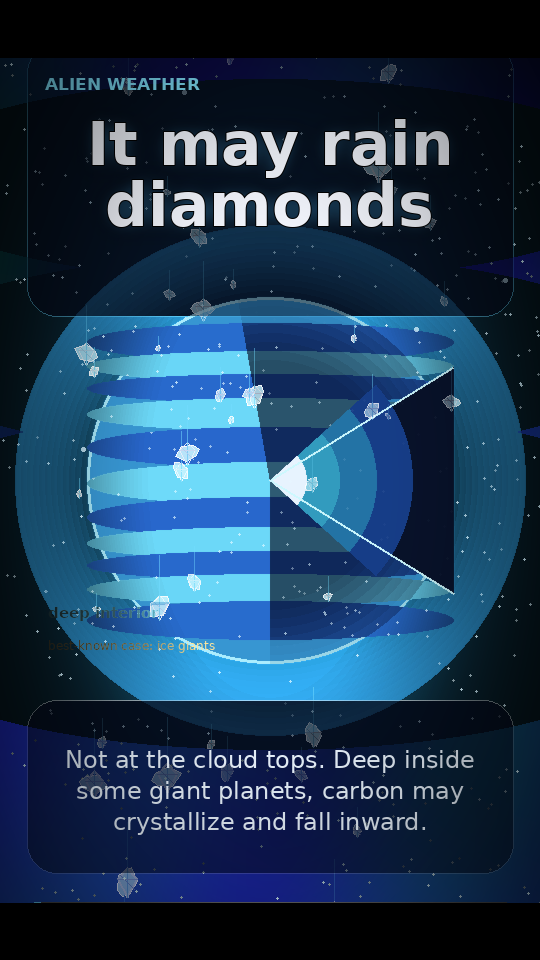

In [5]:
# ==========================
# Frame compositor
# ==========================
SCENE_FUNCS = {
    "hook": scene_hook,
    "worlds": scene_worlds,
    "ingredients": scene_ingredients,
    "pressure": scene_pressure,
    "chemistry": scene_chemistry,
    "nucleation": scene_nucleation,
    "rain": scene_rain,
    "lab": scene_lab,
    "magnetism": scene_magnetism,
    "exoplanets": scene_exoplanets,
    "takeaway": scene_takeaway,
}

def scene_for_time(t: float) -> tuple[dict, float]:
    for scene in SCENES:
        if scene["start"] <= t < scene["end"]:
            local = (t - scene["start"]) / (scene["end"] - scene["start"])
            return scene, clamp(local)
    scene = SCENES[-1]
    return scene, 1.0

def add_transition_wipe(img: Image.Image, local: float):
    edge = max(smoothstep(0.0, 0.06, local), smoothstep(1.0, 0.94, local))
    if edge <= 0:
        return
    d = ImageDraw.Draw(img, "RGBA")
    h = int(H * 0.06 * edge)
    d.rectangle([0, 0, W, h], fill=(0,0,0,int(160*edge)))
    d.rectangle([0, H-h, W, H], fill=(0,0,0,int(160*edge)))

def make_frame(frame_idx: int) -> np.ndarray:
    t = frame_idx / FPS
    scene, local = scene_for_time(t)

    bg = nebula_background(t, hue_shift=SCENES.index(scene) * 0.37)
    img = bg.convert("RGBA")

    # Technical grid overlay for science/mechanism scenes.
    if scene["kind"] in {"pressure", "chemistry", "nucleation", "lab", "magnetism"}:
        grid = Image.new("RGBA", img.size, (0,0,0,0))
        gd = ImageDraw.Draw(grid, "RGBA")
        step = max(36, W//12)
        for x in range(0, W, step):
            gd.line([x, 0, x, H], fill=(105,214,255,14), width=1)
        for y in range(0, H, step):
            gd.line([0, y, W, y], fill=(105,214,255,12), width=1)
        img.alpha_composite(grid)

    SCENE_FUNCS[scene["kind"]](img, t, local)

    draw_scene_text(img, scene, local)
    draw_progress(img, t)
    add_transition_wipe(img, local)
    add_vignette(img, 0.53)

    return np.array(img.convert("RGB"))

# Quick sanity preview of one frame
Image.fromarray(make_frame(int(2.0 * FPS)))


Saved storyboard preview: diamond_rain_output/Diamond_Rain_Storyboard.png


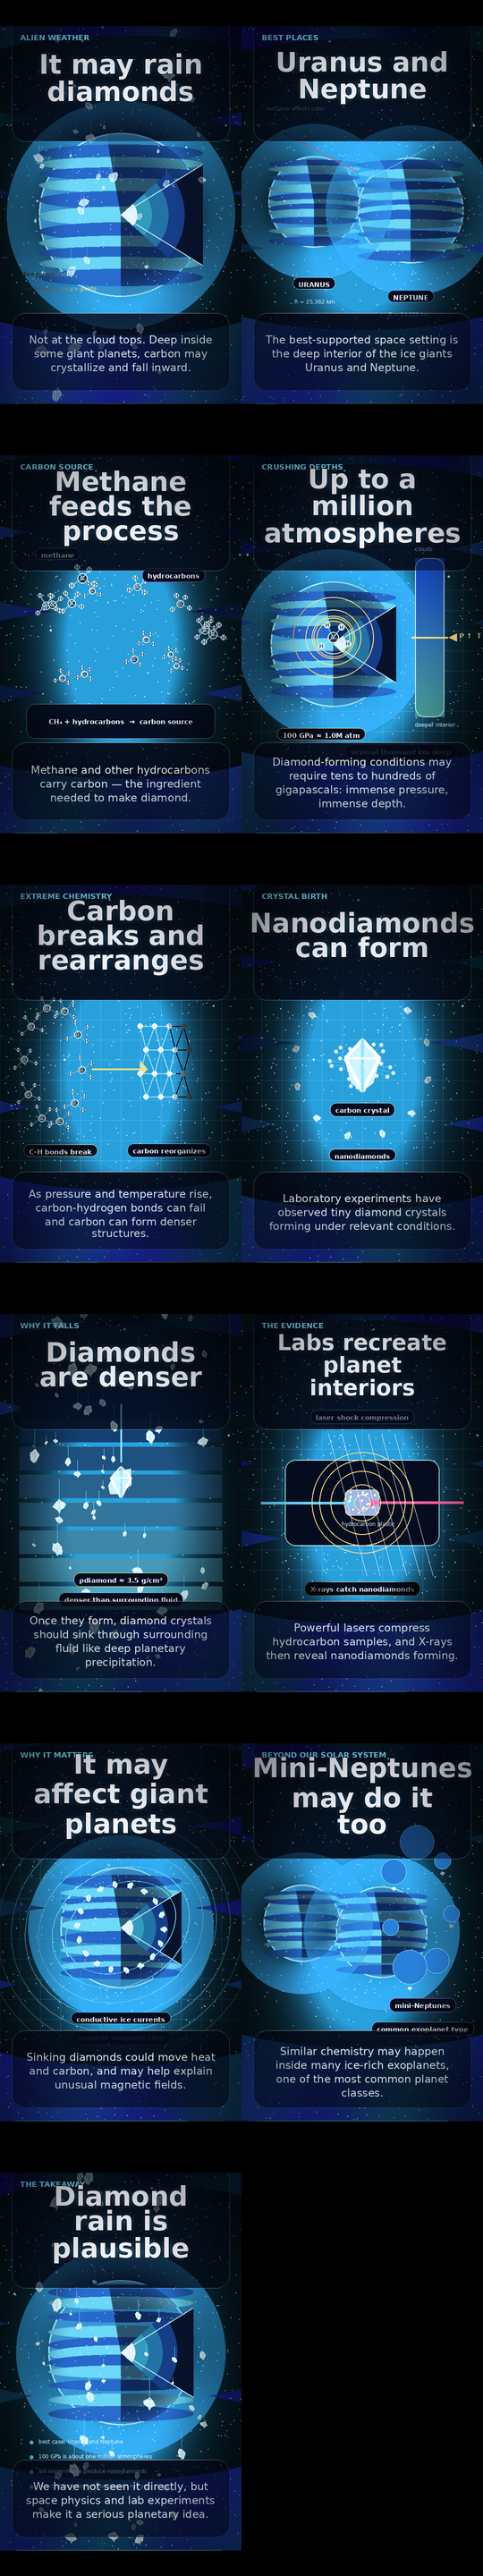

In [6]:
# ==========================
# Render storyboard preview
# ==========================
preview_times = [2.0, 9.0, 18.0, 27.0, 35.0, 44.0, 53.0, 62.0, 72.0, 80.0, 86.0]
frames = [Image.fromarray(make_frame(int(t * FPS))) for t in preview_times]

thumb_w = W // 2
thumb_h = H // 2
cols = 2
rows = math.ceil(len(frames) / cols)
contact = Image.new("RGB", (thumb_w * cols, thumb_h * rows), (0, 0, 0))
for idx, frame in enumerate(frames):
    thumb = frame.resize((thumb_w, thumb_h), Image.Resampling.LANCZOS)
    contact.paste(thumb, ((idx % cols) * thumb_w, (idx // cols) * thumb_h))

contact.save(STORYBOARD_NAME, quality=95)
print(f"Saved storyboard preview: {STORYBOARD_NAME}")
contact


In [7]:
# ==========================
# Render the full vertical video
# ==========================
# Tip: keep DRAFT_MODE=True for testing. Set DRAFT_MODE=False in the config cell for a sharper final export.
writer = imageio.get_writer(
    VIDEO_NAME,
    fps=FPS,
    codec="libx264",
    quality=8 if DRAFT_MODE else 9,
    pixelformat="yuv420p",
    macro_block_size=16,
)

for frame_idx in tqdm(range(NFRAMES), desc="Rendering diamond-rain explainer"):
    writer.append_data(make_frame(frame_idx))

writer.close()

print(f"Saved video: {VIDEO_NAME}")
print(f"Duration: {VIDEO_SECONDS:.1f}s | FPS: {FPS} | Size: {W}x{H}")


Rendering diamond-rain explainer:   0%|          | 0/1584 [00:00<?, ?it/s]

IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (540, 960) to (544, 960) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


Saved video: diamond_rain_output/Diamond_Rain_Cinematic_Explainer.mp4
Duration: 88.0s | FPS: 18 | Size: 540x960


In [ ]:
# Display video inside the notebook, if supported
from IPython.display import Video, display

display(Video(str(VIDEO_NAME), embed=True, html_attributes="controls autoplay loop"))


## What this notebook explains

This version is designed to be **more space-focused and more scientifically grounded** than the first draft.

### Main story

The video explains why scientists think **diamond rain could happen deep inside Uranus and Neptune**:

1. **Pick the planetary setting**: the best-supported setting is the interior of the ice giants **Uranus** and **Neptune**.
2. **Identify the carbon source**: methane and hydrocarbons provide carbon.
3. **Raise pressure and temperature**: deeper layers reach conditions where ordinary chemistry changes.
4. **Form diamonds**: carbon can rearrange into dense crystal structures.
5. **Let them fall**: because diamond is dense, crystals should sink through the surrounding fluid.
6. **Check with experiments**: lab work at **SLAC/LCLS** and **European XFEL** has observed nanodiamond formation.
7. **Connect to planetary physics**: the process may influence heat transport, carbon transport, and possibly the strange magnetic fields of the ice giants.

### Back-of-the-envelope calculations used in the script

These are **simple scale estimates**, not full interior models.

- **Pressure conversion**:  
  100 GPa ≈ 9.87 × 10⁵ atmospheres, which is close to **one million times Earth’s sea-level pressure**.

- **Depth estimate** using the hydrostatic relation **P ≈ ρgh**:  
  if interior density is roughly **0.7–1.5 g/cm³** and gravity is roughly **8.7–11.2 m/s²**, then reaching **100 GPa** requires **several thousand kilometers** of overlying material.

- **Density contrast**:  
  diamond has a density of about **3.5 g/cm³**, so it is denser than the surrounding deep planetary fluid and should tend to **sink inward** once crystals form.

### Scientific scope and caution

- This is a **hypothesis**, not a directly photographed phenomenon.
- The **strongest evidence** is from **laboratory experiments** and **planetary interior physics**.
- The best-known Solar System candidates are **Uranus and Neptune**.
- Related chemistry may also happen in **mini-Neptune exoplanets**.
- Older theoretical work has also discussed possible diamond formation in **Jupiter and Saturn**, but this notebook keeps the focus on the best-supported ice-giant case.


## Source notes

The built-in script is based on public educational and technical material from **NASA**, **SLAC National Accelerator Laboratory**, **European XFEL**, and peer-reviewed papers on diamond formation under giant-planet interior conditions.

Suggested core references:

- **NASA — Uranus Facts**  
  https://science.nasa.gov/uranus/facts/

- **NASA — Neptune Facts**  
  https://science.nasa.gov/neptune/neptune-facts/

- **NASA Gravity Assist — It’s Raining Diamonds on These Planets**  
  https://www.nasa.gov/podcasts/gravity-assist/gravity-assist-its-raining-diamonds-on-these-planets/

- **SLAC 2017 — Scientists Create Diamond Rain That Forms in the Interior of Icy Giant Planets**  
  https://www6.slac.stanford.edu/news/2017-08-21-scientists-create-diamond-rain-forms-interior-icy-giant-planets

- **SLAC 2022 — Diamond Rain on Giant Icy Planets Could Be More Common Than Previously Thought**  
  https://www6.slac.stanford.edu/news/2022-09-02-diamond-rain-giant-icy-planets-could-be-more-common

- **SLAC 2024 — Diamond Rain in Icy Planets Offers Clues to Magnetic Field Mysteries**  
  https://www6.slac.stanford.edu/news/2024-01-08-diamond-rain-icy-planets-offers-clues-magnetic-field-mysteries

- **European XFEL — New findings on diamond rain**  
  https://www.xfel.eu/news_and_events/news/index_eng.html?openDirectAnchor=2269&two_columns=0

- **Science Advances (2022) — Oxygen-assisted diamond formation under warm dense matter conditions**  
  https://www.science.org/doi/10.1126/sciadv.abo0617

- **Nature Astronomy (2024) — Diamond precipitation dynamics in icy giant interiors**  
  https://www.nature.com/articles/s41550-023-02147-x

### Notes on accuracy

- The notebook deliberately calls diamond rain a **plausible planetary process** rather than a confirmed direct observation.
- The numerical values shown in the video are **order-of-magnitude, explanatory estimates** intended for education.
- If you want, this notebook can be extended further with a dedicated **data/plot section** showing the pressure-depth relation or a comparison between Uranus and Neptune.
